In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import json
import ast

data_path = "/content/drive/MyDrive/ML_Term_Project/DDXPlus/"

train = pd.read_csv(data_path + "train.csv")
validate = pd.read_csv(data_path + "validate.csv")
test = pd.read_csv(data_path + "test.csv")

train.head()

Mounted at /content/drive


,AGE,DIFFERENTIAL_DIAGNOSIS,SEX,PATHOLOGY,EVIDENCES,INITIAL_EVIDENCE
0,18,"[['Bronchitis', 0.19171203430383882], ['Pneumo...",M,URTI,"['E_48', 'E_50', 'E_53', 'E_54_@_V_161', 'E_54...",E_91
1,21,"[['HIV (initial infection)', 0.518950056440760...",M,HIV (initial infection),"['E_9', 'E_27', 'E_50', 'E_51', 'E_53', 'E_54_...",E_50
2,19,"[['Bronchitis', 0.11278064619119596], ['Pneumo...",F,Pneumonia,"['E_53', 'E_54_@_V_179', 'E_54_@_V_192', 'E_55...",E_77
3,34,"[['URTI', 0.23859396799565236], ['Cluster head...",F,URTI,"['E_48', 'E_53', 'E_54_@_V_183', 'E_55_@_V_89'...",E_53
4,36,"[['URTI', 0.23677812769175735], ['Influenza', ...",M,URTI,"['E_49', 'E_50', 'E_53', 'E_54_@_V_183', 'E_55...",E_201


In [11]:
# DATA CHECK

print("1) Dataset sizes")
print("Train:", train.shape)
print("Validation:", validate.shape)
print("Test:", test.shape)

print("\n2) Columns")
print(train.columns.tolist())

print("\n3) Missing values in train")
print(train.isnull().sum())

print("\n4) Number of disease classes")
print(train["PATHOLOGY"].nunique())

print("\n5) Top 10 most common diseases")
print(train["PATHOLOGY"].value_counts().head(10))

1) Dataset sizes
Train: (1025602, 6)
Validation: (132448, 6)
Test: (134529, 6)

2) Columns
['AGE', 'DIFFERENTIAL_DIAGNOSIS', 'SEX', 'PATHOLOGY', 'EVIDENCES', 'INITIAL_EVIDENCE']

3) Missing values in train
AGE                       0
DIFFERENTIAL_DIAGNOSIS    0
SEX                       0
PATHOLOGY                 0
EVIDENCES                 0
INITIAL_EVIDENCE          0
dtype: int64

4) Number of disease classes
49

5) Top 10 most common diseases
PATHOLOGY
URTI                       64368
Viral pharyngitis          61642
Anemia                     50665
HIV (initial infection)    29013
Localized edema            27825
Anaphylaxis                27718
Pulmonary embolism         27468
Influenza                  26812
Bronchitis                 26400
Allergic sinusitis         26203
Name: count, dtype: int64


In [28]:
# PREPROCESSING

from sklearn.preprocessing import MultiLabelBinarizer, LabelEncoder
from scipy.sparse import hstack, csr_matrix

# Convert EVIDENCES text into real Python lists
train_evidences = train["EVIDENCES"].apply(ast.literal_eval)
validate_evidences = validate["EVIDENCES"].apply(ast.literal_eval)
test_evidences = test["EVIDENCES"].apply(ast.literal_eval)

# Convert evidences into binary features
mlb = MultiLabelBinarizer(sparse_output=True)

X_train_evidences = mlb.fit_transform(train_evidences)
X_validate_evidences = mlb.transform(validate_evidences)
X_test_evidences = mlb.transform(test_evidences)

# Convert AGE, SEX and INITIAL_EVIDENCE
train_basic = pd.get_dummies(train[["AGE", "SEX", "INITIAL_EVIDENCE"]]).astype(int)
validate_basic = pd.get_dummies(validate[["AGE", "SEX", "INITIAL_EVIDENCE"]]).astype(int)
test_basic = pd.get_dummies(test[["AGE", "SEX", "INITIAL_EVIDENCE"]]).astype(int)

# Make validation and test columns same as train
validate_basic = validate_basic.reindex(columns=train_basic.columns, fill_value=0)
test_basic = test_basic.reindex(columns=train_basic.columns, fill_value=0)

# Combine all features
X_train = hstack([csr_matrix(train_basic), X_train_evidences])
X_validate = hstack([csr_matrix(validate_basic), X_validate_evidences])
X_test = hstack([csr_matrix(test_basic), X_test_evidences])

# Convert target labels
label_encoder = LabelEncoder()

y_train = label_encoder.fit_transform(train["PATHOLOGY"])
y_validate = label_encoder.transform(validate["PATHOLOGY"])
y_test = label_encoder.transform(test["PATHOLOGY"])

print("X_train shape:", X_train.shape)
print("X_validate shape:", X_validate.shape)
print("X_test shape:", X_test.shape)
print("Number of classes:", len(label_encoder.classes_))

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['E_133_@_V_186'] will be ignored
  warnings.warn(


X_train shape: (1025602, 614)
X_validate shape: (132448, 614)
X_test shape: (134529, 614)
Number of classes: 49


In [29]:
# MODEL 1 - LOGISTIC REGRESSION

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_validate)

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_validate, log_pred))
print("Precision:", precision_score(y_validate, log_pred, average="weighted"))
print("Recall:", recall_score(y_validate, log_pred, average="weighted"))
print("F1-score:", f1_score(y_validate, log_pred, average="weighted"))
print("MCC:", matthews_corrcoef(y_validate, log_pred))

Logistic Regression Results
Accuracy: 0.9971233993718289
Precision: 0.997330810259549
Recall: 0.9971233993718289
F1-score: 0.9970861976728462
MCC: 0.9970448339750164


In [30]:
# GRID SEARCH FOR DECISION TREE

from sklearn.tree import DecisionTreeClassifier

depth_values = [20, 30, 40, 50]

tree_results = []

for depth in depth_values:
    tree_model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree_model.fit(X_train, y_train)

    tree_pred = tree_model.predict(X_validate)

    acc = accuracy_score(y_validate, tree_pred)
    f1 = f1_score(y_validate, tree_pred, average="weighted")

    tree_results.append([depth, acc, f1])

    print("max_depth:", depth)
    print("Accuracy:", acc)
    print("F1-score:", f1)
    print()

max_depth: 20
Accuracy: 0.7305659579608601
F1-score: 0.7264820307566424

max_depth: 30
Accuracy: 0.9614112708383667
F1-score: 0.9646432313456256

max_depth: 40
Accuracy: 0.9891580091809616
F1-score: 0.9893060019641793

max_depth: 50
Accuracy: 0.9931369292099541
F1-score: 0.9931651005009146



In [31]:
# DECISION TREE GRID SEARCH RESULTS

tree_results_df = pd.DataFrame(
    tree_results,
    columns=["max_depth", "Accuracy", "F1-score"]
)

tree_results_df

,max_depth,Accuracy,F1-score
0,20,0.730566,0.726482
1,30,0.961411,0.964643
2,40,0.989158,0.989306
3,50,0.993137,0.993165


In [32]:
# FINAL DECISION TREE MODEL

best_depth = tree_results_df.sort_values(by="F1-score", ascending=False).iloc[0]["max_depth"]

tree_model = DecisionTreeClassifier(max_depth=int(best_depth), random_state=42)
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_validate)

print("Best max_depth:", int(best_depth))
print("Decision Tree Results")
print("Accuracy:", accuracy_score(y_validate, tree_pred))
print("Precision:", precision_score(y_validate, tree_pred, average="weighted", zero_division=0))
print("Recall:", recall_score(y_validate, tree_pred, average="weighted"))
print("F1-score:", f1_score(y_validate, tree_pred, average="weighted"))
print("MCC:", matthews_corrcoef(y_validate, tree_pred))

Best max_depth: 50
Decision Tree Results
Accuracy: 0.9931369292099541
Precision: 0.9932558873323494
Recall: 0.9931369292099541
F1-score: 0.9931651005009146
MCC: 0.9929397427263218


In [33]:
# MODEL 3 - RANDOM FOREST

from sklearn.ensemble import RandomForestClassifier

forest_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=50,
    random_state=42,
    n_jobs=-1
)

forest_model.fit(X_train, y_train)

forest_pred = forest_model.predict(X_validate)

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_validate, forest_pred))
print("Precision:", precision_score(y_validate, forest_pred, average="weighted", zero_division=0))
print("Recall:", recall_score(y_validate, forest_pred, average="weighted"))
print("F1-score:", f1_score(y_validate, forest_pred, average="weighted"))
print("MCC:", matthews_corrcoef(y_validate, forest_pred))

Random Forest Results
Accuracy: 0.9966552911331239
Precision: 0.9969465087583812
Recall: 0.9966552911331239
F1-score: 0.9966029865619285
MCC: 0.9965651103889526


In [34]:
# MODEL COMPARISON ON VALIDATION SET

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_validate, log_pred),
        accuracy_score(y_validate, tree_pred),
        accuracy_score(y_validate, forest_pred)
    ],
    "Precision": [
        precision_score(y_validate, log_pred, average="weighted", zero_division=0),
        precision_score(y_validate, tree_pred, average="weighted", zero_division=0),
        precision_score(y_validate, forest_pred, average="weighted", zero_division=0)
    ],
    "Recall": [
        recall_score(y_validate, log_pred, average="weighted"),
        recall_score(y_validate, tree_pred, average="weighted"),
        recall_score(y_validate, forest_pred, average="weighted")
    ],
    "F1-score": [
        f1_score(y_validate, log_pred, average="weighted"),
        f1_score(y_validate, tree_pred, average="weighted"),
        f1_score(y_validate, forest_pred, average="weighted")
    ],
    "MCC": [
        matthews_corrcoef(y_validate, log_pred),
        matthews_corrcoef(y_validate, tree_pred),
        matthews_corrcoef(y_validate, forest_pred)
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-score,MCC
0,Logistic Regression,0.997123,0.997331,0.997123,0.997086,0.997045
1,Decision Tree,0.993137,0.993256,0.993137,0.993165,0.992940
2,Random Forest,0.996655,0.996947,0.996655,0.996603,0.996565


In [35]:
# FINAL TEST RESULTS WITH BEST MODEL

best_model = log_model

test_pred = best_model.predict(X_test)

print("Final Test Results - Logistic Regression")
print("Accuracy:", accuracy_score(y_test, test_pred))
print("Precision:", precision_score(y_test, test_pred, average="weighted", zero_division=0))
print("Recall:", recall_score(y_test, test_pred, average="weighted"))
print("F1-score:", f1_score(y_test, test_pred, average="weighted"))
print("MCC:", matthews_corrcoef(y_test, test_pred))

Final Test Results - Logistic Regression
Accuracy: 0.9974800972281069
Precision: 0.997632509629317
Recall: 0.9974800972281069
F1-score: 0.9974506546248126
MCC: 0.9974111182507517


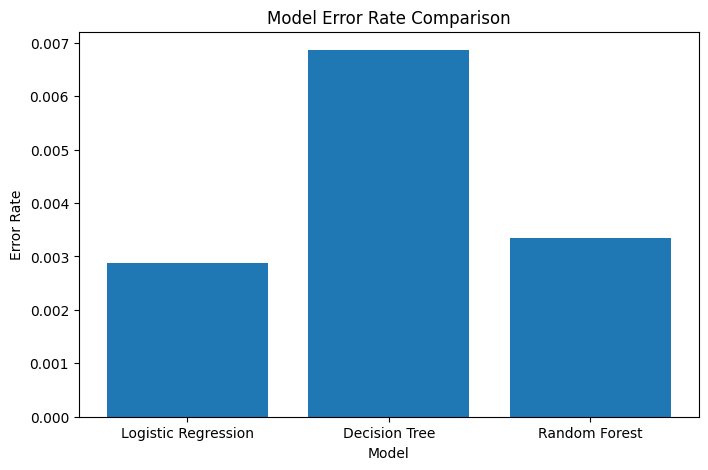

In [37]:
# MODEL COMPARISON GRAPH

import matplotlib.pyplot as plt

results["Error Rate"] = 1 - results["Accuracy"]

plt.figure(figsize=(8, 5))
plt.bar(results["Model"], results["Error Rate"])

plt.title("Model Error Rate Comparison")
plt.xlabel("Model")
plt.ylabel("Error Rate")

plt.show()

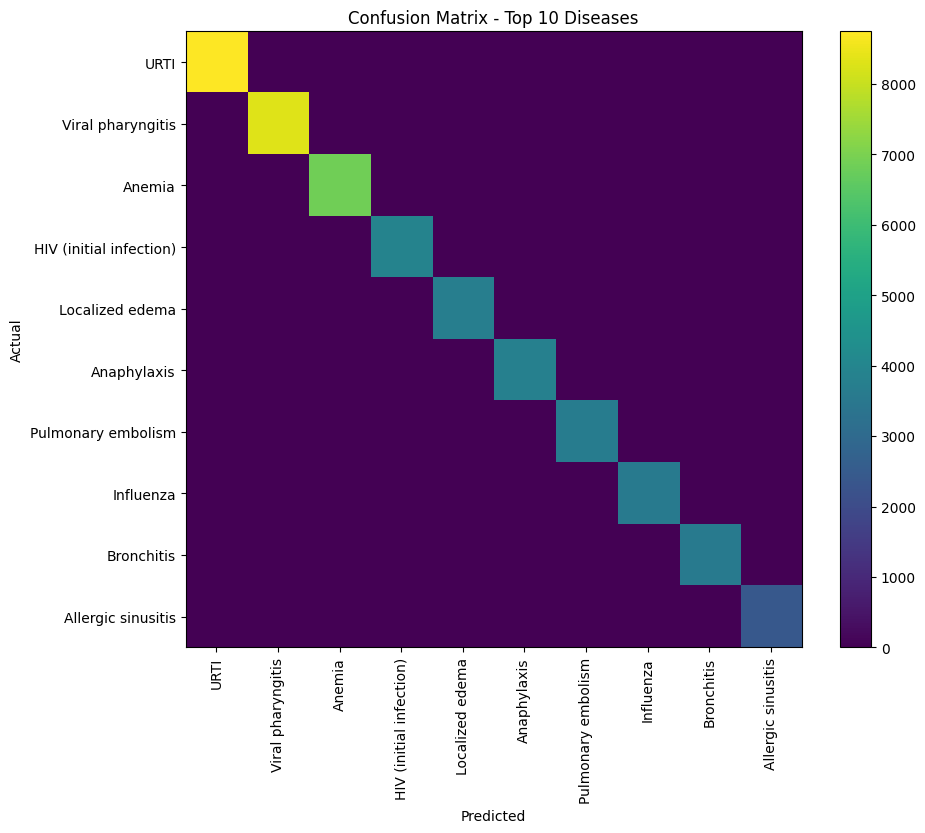

In [38]:
# CONFUSION MATRIX FOR TOP 10 DISEASES

from sklearn.metrics import confusion_matrix

top_10_diseases = train["PATHOLOGY"].value_counts().head(10).index
top_10_labels = label_encoder.transform(top_10_diseases)

y_test_series = pd.Series(y_test)
test_pred_series = pd.Series(test_pred)

mask = y_test_series.isin(top_10_labels)

cm = confusion_matrix(
    y_test_series[mask],
    test_pred_series[mask],
    labels=top_10_labels
)

plt.figure(figsize=(10, 8))
plt.imshow(cm)
plt.title("Confusion Matrix - Top 10 Diseases")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

plt.xticks(range(len(top_10_diseases)), top_10_diseases, rotation=90)
plt.yticks(range(len(top_10_diseases)), top_10_diseases)

plt.show()

## Results and Discussion

In this project, we trained three different classification models to predict the patient's pathology using the DDXPlus dataset. The input features were age, sex, initial evidence, and the evidence list of each patient. The target variable was "PATHOLOGY".

The three models used in this project were:

- Logistic Regression
- Decision Tree
- Random Forest

Before training the models, the "EVIDENCES" column was converted into binary features. The categorical columns such as "SEX" and "INITIAL_EVIDENCE" were also converted into numerical form. The "DIFFERENTIAL_DIAGNOSIS" column was not used as an input feature because it already contains diagnosis-related information.

According to the validation results, Logistic Regression achieved the best overall performance. Random Forest also performed very well and had very close results to Logistic Regression. Decision Tree gave slightly lower results compared to the other two models, but its performance improved after testing different "max_depth" values.

The validation results showed that all models performed well, especially Logistic Regression and Random Forest. Since the accuracy values were very close to 1, error rate was also plotted to make the model comparison clearer.

The best model was selected as Logistic Regression based on the validation results. It was then tested on the test set, where it also achieved very high performance.
